# Import libs

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
import os
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F

In [ ]:
model_name = "kuleshov-group/caduceus-ph_seqlen-131k_d_model-256_n_layer-16"
tokenizer_caduseus = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
config_caduseus = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config_caduseus.bidirectional_weight_tie = False
model_caduseus = AutoModel.from_pretrained('your_path', trust_remote_code=True, config=config_caduseus)
model = CADUSEUS_for_token_classification(model_caduseus)

seq = ['ATCGATCGATCGATCG']

tokenized_data = tokenizer(seq, return_tensors='pt')

result = model(**tokenized_data)['logits']

# Configure model

In [3]:
os.chdir('/home/jovyan/dnalm/')

In [4]:
from transformers import AutoTokenizer, AutoConfig
tokenizer = AutoTokenizer.from_pretrained('./data/tokenizers/t2t_1000h_multi_32k/')

/home/jovyan/dnalm/my_saved_conda_envs/gena/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from src.gena_lm.modeling_bert import BertForLetterLevelTokenClassification

In [6]:
model_cfg = AutoConfig.from_pretrained('./data/configs/L24-H1024-A16-V32k-preln-lastln.json') # here it soulbe config for backbone model, don't change it, you can change only path to it
model_cls = BertForLetterLevelTokenClassification
model = model_cls(config=model_cfg)

In [7]:
from transformers import GPT2LMHeadModel

In [8]:
model_cfg = AutoConfig.from_pretrained('./data/configs/GPT2.json')
model_cls = GPT2LMHeadModel
decoder = model_cls(config=model_cfg)

In [9]:
rmt_config = {
    'num_mem_tokens': 5,
    'max_n_segments': 100000,
    'input_size': 512,
    'decoder_chunk_size': 1024,
    'decoder_look_back_size': 512,
    'bptt_depth': -1,
    'sum_loss': True,
    'tokenizer': tokenizer
}

from src.gena_lm.modeling_rmt import RMTEncoderDecoderValidation
rmt_cls = RMTEncoderDecoderValidation
model = rmt_cls(model, decoder, **rmt_config)

In [10]:
# load pre-trained weights
ckpt = torch.load(str('/home/jovyan/dnalm/runs/annotation_encoder_bert_large_24_classes_GPT2_1024_decoder_4k_with_overlaps_no_loss_weights_with_all_embeddings_in_decoder_avg_hyperparameters/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len4096_maxnsegm_10000_msz_5_bptt-1_lr5e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs_it500000/run_1/model_best/pytorch_model.bin'))
missing_k, unexpected_k = model.load_state_dict(ckpt, strict=False)
print(f'missing: {missing_k}') # if no missing tensors - that is correct, otherwise - no!
print(f'unexpected_k: {unexpected_k}') # if no missing tensors - that is correct, otherwise - no!

missing: ['decoder.transformer.h.2.ln_1.weight', 'decoder.transformer.h.2.ln_1.bias', 'decoder.transformer.h.2.attn.c_attn.weight', 'decoder.transformer.h.2.attn.c_attn.bias', 'decoder.transformer.h.2.attn.c_proj.weight', 'decoder.transformer.h.2.attn.c_proj.bias', 'decoder.transformer.h.2.ln_2.weight', 'decoder.transformer.h.2.ln_2.bias', 'decoder.transformer.h.2.crossattention.c_attn.weight', 'decoder.transformer.h.2.crossattention.c_attn.bias', 'decoder.transformer.h.2.crossattention.q_attn.weight', 'decoder.transformer.h.2.crossattention.q_attn.bias', 'decoder.transformer.h.2.crossattention.c_proj.weight', 'decoder.transformer.h.2.crossattention.c_proj.bias', 'decoder.transformer.h.2.ln_cross_attn.weight', 'decoder.transformer.h.2.ln_cross_attn.bias', 'decoder.transformer.h.2.mlp.c_fc.weight', 'decoder.transformer.h.2.mlp.c_fc.bias', 'decoder.transformer.h.2.mlp.c_proj.weight', 'decoder.transformer.h.2.mlp.c_proj.bias', 'decoder.transformer.h.3.ln_1.weight', 'decoder.transformer.h.

In [11]:
model = model.eval().to('cuda')
model.half()

RMTEncoderDecoderValidation(
  (model): BertForLetterLevelTokenClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(32005, 1024, padding_idx=3)
        (position_embeddings): Embedding(512, 1024)
        (token_type_embeddings): Embedding(2, 1024)
        (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-23): 24 x BertLayer(
            (pre_attention_ln): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (post_attention_ln): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (attention): BertAttention(
              (self): BertSelfFlashAttention(
                (query): Linear(in_features=1024, out_features=1024, bias=True)
                (key): Linear(in_features=1024, out_features=1024, bias=True)
                (value): Linear(in_features=1024

# Valid dataset

In [1]:
import h5py

In [2]:
dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/decoder/gena_decoder_val.hdf5', "r")

In [3]:
len(list(dataset_file.keys()))

24346

In [60]:
12173 * 2

24346

In [45]:
tss_polya_counter_not_first = 0

for i in range(len(list(dataset_file.keys()))):
    tr = np.array(dataset_file[f'transcript_{i}']["labels"])[:90000] # 32768
    if (21 in tr or 22 in tr) and tr[0] != 21 and tr[0] != 22:
        tss_polya_counter_not_first += 1

In [46]:
tss_polya_counter_not_first

12173

In [61]:
7346 / 12173

0.6034666885730715

In [9]:
75000 * 32000

2400000000

In [8]:
counter = 0

for i in range(len(list(dataset_file.keys()))):
    tr = np.array(dataset_file[f'transcript_{i}']["labels"])[:32768]
    if (tr[0] == 21 or tr[0] == 22) and tr[-1] == 23:
        counter += 1
counter

5923

In [43]:
tss_polya_counter_not_first = 0

for i in range(len(list(dataset_file.keys()))):
    tr = np.array(dataset_file[f'transcript_{i}']["labels"])[:32768]
    if (21 in tr or 22 in tr) and tr[0] != 21 and tr[0] != 22:
        tss_polya_counter_not_first += 1

In [44]:
tss_polya_counter_not_first

7346

In [15]:
transcript_idx = 10000
tokenizer.decode(np.array(dataset_file[f'transcript_{transcript_idx}']["token_atcg"]))[:100]

'TTGTTCTAAAAAAAATTAAACCTTTTTATTAGTATATTTATTTTATATATAAAAGAAATACAAAAAAAAAAAAAAACAGAAAGAAAATGCTTTTATGGCA'

In [16]:
dataset_seq = tokenizer.decode(np.array(dataset_file[f'transcript_{transcript_idx}']["token_atcg"]))

In [17]:
np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[:100]

array([22, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 14,  1,  0,  2,  1,  0,  2,  1])

In [59]:
tokenizer(['G'], return_tensors='np')

{'input_ids': array([[1, 9, 2]]), 'token_type_ids': array([[0, 0, 0]]), 'attention_mask': array([[1, 1, 1]])}

In [57]:
tokenizer.decode([6, 15, 8, 9])

'ATCG'

# Evaluation example

In [18]:
def prepare_sequence(sequence, tokenizer):
    model_input = dict()
    input_features = tokenizer([sequence], return_tensors='np')
    
#    print(input_features['input_ids'].shape)
    
    model_input['input_ids'] = input_features['input_ids']
    model_input['token_type_ids'] = input_features['token_type_ids']
    model_input['attention_mask'] = input_features['attention_mask']
    # model_input['labels'] = np.random.randint(0, 5, (1, model_input['input_ids'].shape[1], 5)) # change it in future
    # model_input['labels_ohe'] = torch.randint(0, 6, (model_input['input_ids'].shape[0], 6)) # change it in future
    model_input['labels_mask'] = (input_features['input_ids'] > 5).astype(int)
    
    token_repeater_numbers = []
    meaningful_tokens_only = model_input['input_ids'][model_input['input_ids'] > 5]
    for t in meaningful_tokens_only:
        atcg_seq_token = tokenizer.convert_ids_to_tokens(int(t))
        token_repeater_numbers.append(len(atcg_seq_token))
    
    token_repeater = []
    for n, i in enumerate(token_repeater_numbers):
        # print(i)
        for j in range(i):
            token_repeater.append(n)
    
    letter_level_tokens = []
    for letter in sequence:
        letter_level_tokens.append(tokenizer.convert_tokens_to_ids(letter))
        
    # if len(letter_level_tokens) < max_length:
    #     letter_level_tokens += [-100] * (max_length - len(letter_level_tokens))
    #     token_repeater = token_repeater + [-100] * (max_length - len(token_repeater))

    model_input['letter_level_attention_mask'] = np.expand_dims(np.ones(len(letter_level_tokens)).astype(int), axis=0) # it's okay because we will truncate paddings with mask
    model_input['letter_level_token_types_ids'] = np.expand_dims(np.zeros(len(letter_level_tokens)).astype(int), axis=0)
    model_input['letter_level_tokens'] = np.expand_dims(np.array(letter_level_tokens), axis=0)
    # model_input['letter_level_labels'] = np.array([[24] + [0] * len(letter_level_tokens)]) # np.random.randint(0, 5, (1, len(letter_level_tokens), 5)) # change it in future
    model_input['letter_level_labels_mask'] = model_input['letter_level_tokens'] != -100 #  model_input['letter_level_labels'] != -100
    model_input['embedding_repeater'] = np.expand_dims(np.array(token_repeater), axis=0)
    
    for k, v in model_input.items():
        model_input[k] = torch.tensor(v)
        print(k, v.shape)
    
    return model_input

In [19]:
# import random

# # Define the length of the sequence and the nucleotides
# sequence_length = 10000
# nucleotides = ['A', 'T', 'C', 'G']

# # Generate a sequence with equal probability for each nucleotide
# sequence = ''.join(random.choices(nucleotides, k=sequence_length))

with open('./downstream_tasks/annotation/10M.fa', 'r') as f:
    for line in f:
        print(len(line))

# sequence = line[1932462:1972348].upper()
# sequence = line[1932462:1932462+16000].upper()
sequence = dataset_seq[:32768]

10000000


In [20]:
sequence[10:30]

'AAAAATTAAACCTTTTTATT'

In [21]:
def prediction(transcript_seq, model):
    
    seq = transcript_seq

    model_input_data = prepare_sequence(seq, tokenizer)
    for k, v in model_input_data.items():
        model_input_data[k] = v.to("cuda")

    with torch.no_grad():
        # model.forward(**model_input_data)
        out = model.generate(model_input_data, generate_the_most_probable=True, threshold=0.2, temperature=0.9, 
                             targets_without_bos_token=None)

    return out

In [22]:
gene_dict = prediction(sequence, model)

input_ids (1, 5208)
token_type_ids (1, 5208)
attention_mask (1, 5208)
labels_mask (1, 5208)
letter_level_attention_mask (1, 32768)
letter_level_token_types_ids (1, 32768)
letter_level_tokens (1, 32768)
letter_level_labels_mask (1, 32768)
embedding_repeater (1, 32768)


/home/jovyan/dnalm/my_saved_conda_envs/gena/lib/python3.9/site-packages/transformers/modeling_utils.py:1101: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


CURR LOGITS SHAPE torch.Size([1, 5206, 1024])


100%|██████████| 32768/32768 [02:22<00:00, 230.34it/s]


In [24]:
np.array(gene_dict[:100])

array([22, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16])

In [25]:
# np.save('for_artyom_decoder_output.npy', np.array(gene_dict))

In [26]:
len([22, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 14])

93

In [27]:
np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[:100]

array([22, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 14,  1,  0,  2,  1,  0,  2,  1])

In [28]:
np.array(gene_dict[3300:3400])

array([18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 18, 18, 18, 18, 20, 16, 16, 16, 16, 16, 16])

In [29]:
np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[3300:3400]

array([ 4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4, 10,  0,  2,  1,  0,  2,  1])

In [23]:
select_size = 32768
np.sum(np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[:select_size] == np.array(gene_dict[:select_size])) / select_size

0.0028076171875

In [35]:
w = torch.tensor([11531128.0, 11549727.0, 11531095.0, 1.0, 488589751.0, 265281019.0, 463184462.0, 65733.0, 43130.0, 91413.0, 65774.0, 43172.0, 91380.0, 18329.0, 18394.0, 27016189.0, 27147388.0, 324472532.0, 245528623.0, 38243.0, 38121.0, 23780.0, 23839.0, 552140823.0, 1.0, 1.0])
torch.sum(w) / w

tensor([2.1061e+02, 2.1027e+02, 2.1061e+02, 2.4285e+09, 4.9705e+00, 9.1546e+00,
        5.2431e+00, 3.6945e+04, 5.6307e+04, 2.6567e+04, 3.6922e+04, 5.6253e+04,
        2.6576e+04, 1.3250e+05, 1.3203e+05, 8.9892e+01, 8.9457e+01, 7.4846e+00,
        9.8910e+00, 6.3503e+04, 6.3706e+04, 1.0213e+05, 1.0187e+05, 4.3984e+00,
        2.4285e+09, 2.4285e+09])

In [30]:
import numpy as np
import pandas as pd

def get_label_counts(gene_array):
    label_dict = {0: 'CDS-0', 1:'CDS-1', 2:'CDS-2', 3:'CDS-skip', 4:'intron-0', 5:'intron-1', 6:'intron-2', 7:'ASS-0', 8:'ASS-1', 9:'ASS-2', 10:'DSS-0', 11:'DSS-1', 12:'DSS-2', 13:'START', 14:'STOP', 15:'nc_exon_plus', 16:'nc_exon_minu', 17:'nc_intron_plus', 18:'nc_intron_minus', 19:'nc_ASS', 20:'nc_DSS', 21:'TSS' , 22:'PolyA', 23:'IR'}
    # Use numpy.unique to get the unique labels and their counts
    unique_labels, counts = np.unique(gene_array, return_counts=True)
    
    # Map each unique label to its corresponding name using label_dict
    label_names = [label_dict[label] for label in unique_labels]
    
    # Create and return the DataFrame
    df = pd.DataFrame({
        'label name': label_names,
        'count value': counts
    })
    return df

In [31]:
get_label_counts(gene_dict)

NameError: name 'gene_dict' is not defined

In [32]:
get_label_counts(np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[:32768])

,label name,count value
0,CDS-0,281
1,CDS-1,281
2,CDS-2,280
3,intron-0,2812
4,intron-2,29014
5,ASS-0,1
6,ASS-2,3
7,DSS-0,1
8,DSS-2,2
9,STOP,1


In [27]:
np.unique(np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[:90000], return_counts=True)

(array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 14, 16, 22]),
 array([  549,   549,   548,  2812, 32883, 52547,     1,     2,     7,
            1,     2,     6,     1,    91,     1]))

In [ ]:
np.unique(gene_dict, return_counts=True)

In [ ]:
# top_values.index(10)

In [ ]:
# generated_seq = prediction(sequence, model)

In [ ]:
# generated_seq

In [ ]:
# start = 85000
# generated_seq[start:start+1000]

In [ ]:
# len(generated_seq)

# Compare classes

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import os
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F

os.chdir('/home/jovyan/dnalm/')
from transformers import AutoTokenizer, AutoConfig
tokenizer = AutoTokenizer.from_pretrained('./data/tokenizers/t2t_1000h_multi_32k/')
from src.gena_lm.modeling_bert import BertForLetterLevelTokenClassification
model_cfg = AutoConfig.from_pretrained('./data/configs/L24-H1024-A16-V32k-preln-lastln.json') # here it soulbe config for backbone model, don't change it, you can change only path to it
model_cls = BertForLetterLevelTokenClassification
model = model_cls(config=model_cfg)
from transformers import GPT2LMHeadModel
model_cfg = AutoConfig.from_pretrained('./data/configs/GPT2.json')
model_cls = GPT2LMHeadModel
decoder = model_cls(config=model_cfg)
rmt_config = {
    'num_mem_tokens': 5,
    'max_n_segments': 100000,
    'input_size': 512,
    'decoder_chunk_size': 1024,
    'decoder_look_back_size': 512,
    'bptt_depth': -1,
    'sum_loss': True,
    'tokenizer': tokenizer
}

from src.gena_lm.modeling_rmt import RMTEncoderDecoderValidation
rmt_cls = RMTEncoderDecoderValidation
model = rmt_cls(model, decoder, **rmt_config)
# load pre-trained weights
ckpt = torch.load(str('/home/jovyan/dnalm/runs/annotation_decoder_with_2k_intergenic_only_1024/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len4096_maxnsegm_10000_msz_5_bptt-1_lr5e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs_it500000/run_1/model_best/pytorch_model.bin'))
missing_k, unexpected_k = model.load_state_dict(ckpt, strict=False)
print(f'missing: {missing_k}') # if no missing tensors - that is correct, otherwise - no!
print(f'unexpected_k: {unexpected_k}') # if no missing tensors - that is correct, otherwise - no!
model_val = model.eval().to('cuda')
model_val.half()

os.chdir('/home/jovyan/dnalm/')
from transformers import AutoTokenizer, AutoConfig
tokenizer = AutoTokenizer.from_pretrained('./data/tokenizers/t2t_1000h_multi_32k/')
from src.gena_lm.modeling_bert import BertForLetterLevelTokenClassification
model_cfg = AutoConfig.from_pretrained('./data/configs/L24-H1024-A16-V32k-preln-lastln.json') # here it soulbe config for backbone model, don't change it, you can change only path to it
model_cls = BertForLetterLevelTokenClassification
model = model_cls(config=model_cfg)
from transformers import GPT2LMHeadModel
model_cfg = AutoConfig.from_pretrained('./data/configs/GPT2.json')
model_cls = GPT2LMHeadModel
decoder = model_cls(config=model_cfg)
rmt_config = {
    'num_mem_tokens': 5,
    'max_n_segments': 100000,
    'input_size': 512,
    'decoder_chunk_size': 1024,
    'decoder_look_back_size': 512,
    'bptt_depth': -1,
    'sum_loss': True,
    'tokenizer': tokenizer
}

from src.gena_lm.modeling_rmt import RMTEncoderDecoder
rmt_cls = RMTEncoderDecoder
model = rmt_cls(model, decoder, **rmt_config)
# load pre-trained weights
ckpt = torch.load(str('/home/jovyan/dnalm/runs/annotation_decoder_with_2k_intergenic_only_1024/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len4096_maxnsegm_10000_msz_5_bptt-1_lr5e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs_it500000/run_1/model_best/pytorch_model.bin'))
missing_k, unexpected_k = model.load_state_dict(ckpt, strict=False)
print(f'missing: {missing_k}') # if no missing tensors - that is correct, otherwise - no!
print(f'unexpected_k: {unexpected_k}') # if no missing tensors - that is correct, otherwise - no!
model = model.eval().to('cuda')
model.half()

print('loaded')

/home/jovyan/dnalm/my_saved_conda_envs/gena/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


missing: []
unexpected_k: []
missing: []
unexpected_k: []
loaded


In [2]:
# new model
model.model.bert.encoder.layer[0].attention.self.query.weight

Parameter containing:
tensor([[ 6.4453e-02, -9.6664e-03, -1.0626e-01,  ..., -3.3302e-03,
          2.3102e-02, -7.6782e-02],
        [ 2.5497e-02, -4.6967e-02, -8.2016e-03,  ...,  3.9856e-02,
          3.7689e-02, -3.0632e-03],
        [-3.2501e-02, -2.6550e-02,  4.8431e-02,  ..., -6.4278e-03,
         -3.6133e-02,  1.2756e-01],
        ...,
        [-1.1145e-01, -7.0801e-02,  2.7725e-02,  ...,  1.4160e-01,
          6.8542e-02, -1.3696e-01],
        [-1.1566e-02, -5.7281e-02,  1.0150e-01,  ...,  3.1830e-02,
          7.7576e-02,  1.3125e-04],
        [ 8.6487e-02, -6.0516e-02, -9.6680e-02,  ..., -7.2266e-02,
         -8.0719e-03, -6.2500e-02]], device='cuda:0', dtype=torch.float16,
       requires_grad=True)

In [6]:
# old model
model.model.bert.encoder.layer[0].attention.self.query.weight

Parameter containing:
tensor([[ 6.4453e-02, -9.6664e-03, -1.0626e-01,  ..., -3.3302e-03,
          2.3102e-02, -7.6782e-02],
        [ 2.5497e-02, -4.6967e-02, -8.2016e-03,  ...,  3.9856e-02,
          3.7689e-02, -3.0632e-03],
        [-3.2501e-02, -2.6550e-02,  4.8431e-02,  ..., -6.4278e-03,
         -3.6133e-02,  1.2756e-01],
        ...,
        [-1.1145e-01, -7.0801e-02,  2.7725e-02,  ...,  1.4160e-01,
          6.8542e-02, -1.3696e-01],
        [-1.1566e-02, -5.7281e-02,  1.0150e-01,  ...,  3.1830e-02,
          7.7576e-02,  1.3125e-04],
        [ 8.6487e-02, -6.0516e-02, -9.6680e-02,  ..., -7.2266e-02,
         -8.0719e-03, -6.2500e-02]], device='cuda:0', dtype=torch.float16,
       requires_grad=True)

In [2]:
import h5py
transcript_idx = 870
dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/decoder/gena_decoder_val.hdf5', "r")
dataset_bpe_tokets = np.array(dataset_file[f'transcript_{transcript_idx}']["input_ids"])
dataset_seq_atcg = tokenizer.decode(np.array(dataset_file[f'transcript_{transcript_idx}']["token_atcg"]))
dataset_labels = np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])
print(len(dataset_labels), np.unique(dataset_labels))

30592 [ 0  1  2  5  6  8  9 11 12 13 14 16 18 19 20 21 22 23]


In [2]:
def prepare_sequence(sequence, tokenizer):
    model_input = dict()
    input_features = tokenizer([sequence], return_tensors='np')
    
#    print(input_features['input_ids'].shape)
    
    model_input['input_ids'] = input_features['input_ids']
    model_input['token_type_ids'] = input_features['token_type_ids']
    model_input['attention_mask'] = input_features['attention_mask']
    # model_input['labels'] = np.random.randint(0, 5, (1, model_input['input_ids'].shape[1], 5)) # change it in future
    # model_input['labels_ohe'] = torch.randint(0, 6, (model_input['input_ids'].shape[0], 6)) # change it in future
    model_input['labels_mask'] = (input_features['input_ids'] > 5).astype(int)
    
    token_repeater_numbers = []
    meaningful_tokens_only = model_input['input_ids'][model_input['input_ids'] > 5]
    for t in meaningful_tokens_only:
        atcg_seq_token = tokenizer.convert_ids_to_tokens(int(t))
        token_repeater_numbers.append(len(atcg_seq_token))
    
    token_repeater = []
    for n, i in enumerate(token_repeater_numbers):
        # print(i)
        for j in range(i):
            token_repeater.append(n)
    
    letter_level_tokens = []
    for letter in sequence:
        letter_level_tokens.append(tokenizer.convert_tokens_to_ids(letter))
        
    # if len(letter_level_tokens) < max_length:
    #     letter_level_tokens += [-100] * (max_length - len(letter_level_tokens))
    #     token_repeater = token_repeater + [-100] * (max_length - len(token_repeater))

    model_input['letter_level_attention_mask'] = np.expand_dims(np.ones(len(letter_level_tokens)).astype(int), axis=0) # it's okay because we will truncate paddings with mask
    model_input['letter_level_token_types_ids'] = np.expand_dims(np.zeros(len(letter_level_tokens)).astype(int), axis=0)
    model_input['letter_level_tokens'] = np.expand_dims(np.array(letter_level_tokens), axis=0)
    # model_input['letter_level_labels'] = np.array([[24] + [0] * len(letter_level_tokens)]) # np.random.randint(0, 5, (1, len(letter_level_tokens), 5)) # change it in future
    model_input['letter_level_labels_mask'] = model_input['letter_level_tokens'] != -100 #  model_input['letter_level_labels'] != -100
    model_input['embedding_repeater'] = np.expand_dims(np.array(token_repeater), axis=0)
    
    for k, v in model_input.items():
        model_input[k] = torch.tensor(v)
        print(k, v.shape)
    
    return model_input

def prepare_sequence_forward(sequence, tokenizer, labels):
    model_input = dict()
    input_features = tokenizer([sequence], return_tensors='np')
    
#    print(input_features['input_ids'].shape)
    
    model_input['input_ids'] = input_features['input_ids']
    model_input['token_type_ids'] = input_features['token_type_ids']
    model_input['attention_mask'] = input_features['attention_mask']
    model_input['labels'] = np.random.randint(0, 5, (1, model_input['input_ids'].shape[1], 5)) # change it in future
    # model_input['labels_ohe'] = torch.randint(0, 6, (model_input['input_ids'].shape[0], 6)) # change it in future
    model_input['labels_mask'] = (input_features['input_ids'] > 5).astype(int)
    
    token_repeater_numbers = []
    meaningful_tokens_only = model_input['input_ids'][model_input['input_ids'] > 5]
    for t in meaningful_tokens_only:
        atcg_seq_token = tokenizer.convert_ids_to_tokens(int(t))
        token_repeater_numbers.append(len(atcg_seq_token))
    
    token_repeater = []
    for n, i in enumerate(token_repeater_numbers):
        # print(i)
        for j in range(i):
            token_repeater.append(n)
    
    letter_level_tokens = []
    for letter in sequence:
        letter_level_tokens.append(tokenizer.convert_tokens_to_ids(letter))
        
    # if len(letter_level_tokens) < max_length:
    #     letter_level_tokens += [-100] * (max_length - len(letter_level_tokens))
    #     token_repeater = token_repeater + [-100] * (max_length - len(token_repeater))

    model_input['letter_level_attention_mask'] = np.expand_dims(np.ones(len(letter_level_tokens)).astype(int), axis=0) # it's okay because we will truncate paddings with mask
    model_input['letter_level_token_types_ids'] = np.expand_dims(np.zeros(len(letter_level_tokens)).astype(int), axis=0)
    model_input['letter_level_tokens'] = np.expand_dims(np.array(letter_level_tokens), axis=0)
    model_input['letter_level_labels'] = labels[None, :]
    model_input['letter_level_labels_mask'] = model_input['letter_level_labels'] != -100 #  model_input['letter_level_labels'] != -100
    model_input['embedding_repeater'] = np.expand_dims(np.array(token_repeater), axis=0)
    
    for k, v in model_input.items():
        model_input[k] = torch.tensor(v).to('cuda')
        # print(k, v.shape)
    
    return model_input

def prediction(transcript_seq, model, targets_without_bos_token=None):
    
    seq = transcript_seq

    model_input_data = prepare_sequence(seq, tokenizer)
    for k, v in model_input_data.items():
        model_input_data[k] = v.to("cuda")

    with torch.no_grad():
        # model.forward(**model_input_data)
        out = model.generate(model_input_data, generate_the_most_probable=True, threshold=0.2, temperature=0.9, 
                             targets_without_bos_token=targets_without_bos_token)

    return out

In [3]:
print(len(dataset_file))

NameError: name 'dataset_file' is not defined

In [42]:
import h5py
from tqdm import tqdm
dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/decoder_dataset_2k_correct/gena_decoder_human_val_intergenic_2k.hdf5', "r")

all_preds, all_targets = [], []
for transcript_idx in tqdm(range(len(dataset_file))):
    print(np.array(dataset_file[f'transcript_{transcript_idx}']["coordinates"]))
    dataset_seq_atcg = tokenizer.decode(np.array(dataset_file[f'transcript_{transcript_idx}']["token_atcg"]))
    dataset_labels = np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])

    print(dataset_seq_atcg)
    assert False

    with torch.no_grad():
        gene_pred_forward = model.forward(**prepare_sequence_forward(dataset_seq_atcg, tokenizer, np.concatenate((np.array([24]), dataset_labels), axis=0)))
    gene_pred_forward_processed = torch.argmax(gene_pred_forward['logits'], axis=-1)[0, 1:].detach().cpu().numpy()

    all_preds.append(gene_pred_forward_processed)
    all_targets.append(dataset_labels)

  0%|          | 0/12173 [00:00<?, ?it/s]

[26941 46149 28941 44149]
CAGCTTGGGCAAATAGCAAGACCCTTATGTCTACAAAAAATATATATATATATATTAGATGGCATGCTTGCACATACCTGTAGTCCCAGCTACCCAGGAGGCTGAAGCGGGAGGATTGCTTGAGCCCAGGAGTTCGAGGCTGCAATGAGCCAGCCATAATCGCACCACTGCACTCCAGCCTGGGCGACAGAGTGAGACCCTGTCTCTCTCTCTCTGTCACACACACACACACGTTAAATTTGTTGGATTATATATTTCGGGGGTTGAGCACTTTTCGTTATAAAATATTTATGATTGTGGGAACAAGTTAATAAAGACATGAAAGTTATTTAAATGTCCCAGAACTTTAAGAACAAAAAGCATTCTTAGTTTAAAAATAAGTTTTACTTTAAAGGTAACAGTACACACATAAATTGTTGTTAAAATCGACAGTAACAAAGAGAAGTAACAATACTAATAGCCTGTCACAAACTGATTCTTAATAACCTATATAAACAAACATTAAGCCCGGGCGCCGGGTGGCTCATGCCTGTTATCCCAGCACTTTGGGAAGCCGAGGCAGGCAGATCACTTGAGGCCAGCAGTTCCAGACCAGCCTGACCAACATGGTGAAGCCCAGTCTCTACCAAAAACACAAAAAATTAGCCGGGTATATTGGCACGCACCTGTAATCCCAGCTACTTGGGAGACTGAGGCAGGAGAATCCTTGAACCCAGGAAGCAGAGGTCGCAGTGAGGCGAGACCATGCCATTGTGACAGGAGAGAAACTCTGTCTCAAAAAAAAATTATATGTTTACAACAGGTGCATTTCTCCTCTTGCTTTCTGAGGACGCCCTGCTATGTAGCTGAGTAGTCACTAATAAACTATCTTAACTTCACTATACTCTGTGACTTGCCAAAAGGTCTTTCCCATGTGAAATCCAAAAACCTGTTCTTGGGGTCTAGGACAAGACCCATTTTATAATGACAAAACT

AssertionError: 

In [12]:
3 in all_targets

False

In [6]:
label_dict = {0: 'CDS-0', 1:'CDS-1', 2:'CDS-2', 4:'intron-0', 5:'intron-1', 6:'intron-2', 7:'ASS-0', 8:'ASS-1', 9:'ASS-2', 10:'DSS-0', 11:'DSS-1', 12:'DSS-2', 13:'START', 14:'STOP', 15:'nc_exon_plus', 16:'nc_exon_minu', 17:'nc_intron_plus', 18:'nc_intron_minus', 19:'nc_ASS', 20:'nc_DSS', 21:'TSS' , 22:'PolyA', 23:'IR'}

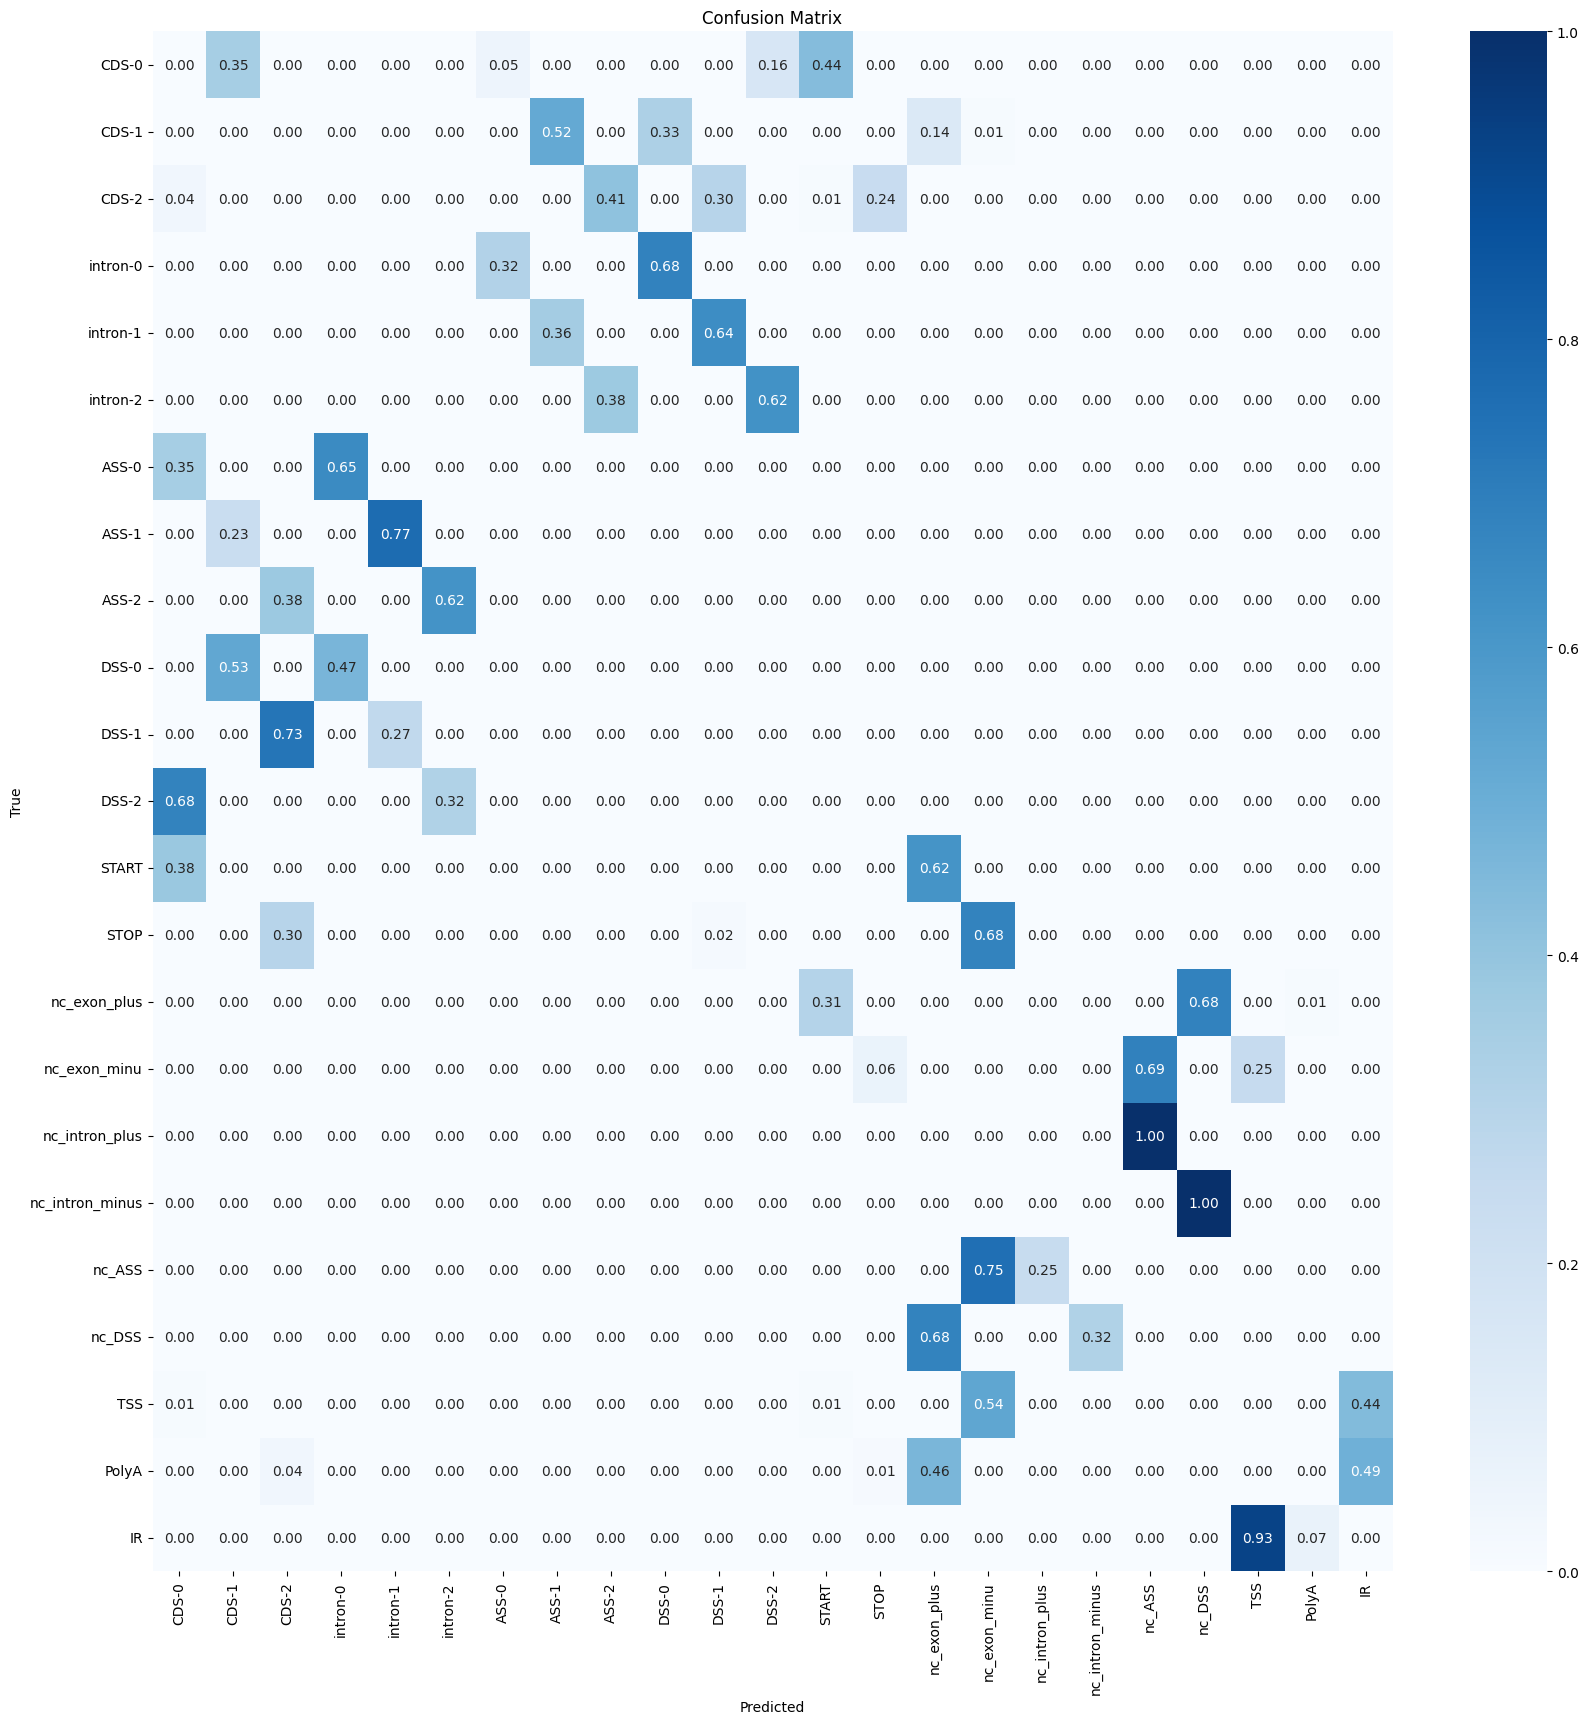

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
cm = confusion_matrix(all_targets, all_preds)

np.fill_diagonal(cm, 0)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(20, 20))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=list(label_dict.values()), yticklabels=list(label_dict.values()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [7]:
all_targets[0].shape

(19208,)

In [4]:
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

In [6]:
gene_pred_generation = prediction(dataset_seq_atcg[:2000], model_val)

input_ids (1, 309)
token_type_ids (1, 309)
attention_mask (1, 309)
labels_mask (1, 309)
letter_level_attention_mask (1, 2000)
letter_level_token_types_ids (1, 2000)
letter_level_tokens (1, 2000)
letter_level_labels_mask (1, 2000)
embedding_repeater (1, 2000)
CURR LOGITS SHAPE torch.Size([1, 307, 1024])


100%|██████████| 2000/2000 [00:20<00:00, 95.45it/s] 


In [5]:
gene_pred_generation

array([[3.8326e-05, 8.2076e-05, 3.5572e-04, ..., 4.1931e-02, 4.8364e-01,
        4.7241e-01],
       [1.3530e-05, 1.1116e-04, 2.5034e-06, ..., 1.6081e-04, 3.5763e-07,
        2.6226e-06],
       [5.9605e-07, 1.5497e-06, 1.4305e-06, ..., 8.4758e-05, 5.9605e-08,
        1.1921e-07],
       ...,
       [1.0133e-06, 2.3246e-06, 7.7486e-07, ..., 2.4052e-03, 2.9802e-07,
        6.5565e-07],
       [9.5367e-07, 2.3246e-06, 7.1526e-07, ..., 2.4147e-03, 2.9802e-07,
        6.5565e-07],
       [4.6492e-06, 6.1393e-06, 6.1393e-06, ..., 6.6528e-02, 1.3351e-05,
        1.4186e-05]], dtype=float16)

In [5]:
np.sum(dataset_labels == gene_pred_generation) / len(dataset_labels)

0.9993135460251046

In [60]:
np.save('gene_pred_generation.npy', gene_pred_generation)

In [47]:
gene_pred_forward = model.forward(**prepare_sequence_forward(dataset_seq_atcg, tokenizer, np.concatenate((np.array([24]), dataset_labels), axis=0)))

input_ids (1, 4670)
token_type_ids (1, 4670)
attention_mask (1, 4670)
labels (1, 4670, 5)
labels_mask (1, 4670)
letter_level_attention_mask (1, 30592)
letter_level_token_types_ids (1, 30592)
letter_level_tokens (1, 30592)
letter_level_labels (1, 30593)
letter_level_labels_mask (1, 30593)
embedding_repeater (1, 30592)


In [58]:
gene_pred_forward_processed = torch.argmax(gene_pred_forward['logits'], axis=-1)[0, 1:].detach().cpu().numpy()

In [59]:
np.sum(dataset_labels == gene_pred_forward_processed) / len(dataset_labels)

0.9991827928870293

In [61]:
np.save('gene_pred_forward_processed.npy', gene_pred_forward_processed)

In [6]:
dataset_labels[:10]

array([22, 16, 16, 16, 16, 16, 16, 16, 16, 16])

# Tensorboard logs

In [2]:
import os
import numpy as np
from tensorboard.backend.event_processing import event_accumulator

os.chdir('/home/jovyan/dnalm/')
# Path to your logs directory
log_dir = 'runs/annotation_encoder_bert_large_24_classes_GPT2_1024_decoder_4k_with_overlaps_no_loss_weights_with_all_embeddings_in_decoder_avg_hyperparameters_shuffle_starts_featured/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len16000_maxnsegm_10000_msz_5_bptt-1_lr5e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs_it500000/run_1/events.out.tfevents.1742236734.anogena-0.1563066.0'  # replace this with actual path

# Load event files
ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

# List all tags (i.e., card names)
all_tags = ea.Tags()

# Only select validation scalar tags
validation_tags = [tag for tag in all_tags['scalars'] if '/valid' in tag]

# Fetch the latest scalar value for each validation tag
latest_scores = []

for tag in validation_tags:
    events = ea.Scalars(tag)
    if events:
        latest_value = events[-1].value  # Get the last value
        latest_scores.append(latest_value)

# Convert to numpy array
validation_scores_np = np.array(latest_scores)

# Print or return it
print("Validation Scores:", np.round(validation_scores_np, 2))


Validation Scores: [ 0.    0.    0.58  0.58  0.99  0.99  1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    0.99  0.99  1.    1.
  1.    1.    1.    1.   -0.   -0.    0.    0.    0.    0.    0.    0.
  1.    1.    0.5   0.5   0.44  0.44  0.56  0.56  1.    1.    0.45  0.45
  0.41  0.41  0.5   0.5   1.    1.    0.51  0.51  0.45  0.45  0.58  0.58
  0.33  0.33  0.57  0.57  0.63  0.63  0.52  0.52  0.26  0.26  0.48  0.48
  0.68  0.68  0.37  0.37  0.41  0.41  0.64  0.64  0.66  0.66  0.61  0.61
  0.48  0.48  0.69  0.69  0.68  0.68  0.69  0.69  0.36  0.36  0.59  0.59
  0.71  0.71  0.5   0.5   0.53  0.53  0.73  0.73  0.71  0.71  0.75  0.75
  0.01  0.01  0.02  0.02  0.86  0.86  0.01  0.01  0.    0.    0.    0.
  0.    0.    0.    0.    1.    1.    0.09  0.09  0.09  0.09  0.1   0.1
  1.    1.    0.04  0.04  0.04  0.04  0.04  0.04  1.    1.    0.25  0.25
  0.23  0.23  0.27  0.27  1.    1.    0.23  0.23  0.21  0.21  0.26  0.26
  0.11  0.11  0.27  0.27  0.55  0.55  0.1

In [1]:
from tensorboard.backend.event_processing import event_accumulator
from collections import OrderedDict
import os

os.chdir('/home/jovyan/')
# Path to your logs directory
log_dir = 'dnalm/runs/annotation_decoder_with_2k_intergenic_only_1024_selected_start_less_1500_weighted_4_classes_recall_TSS_level_selection/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len4096_maxnsegm_10000_msz_5_bptt-1_lr5e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs_it500000/run_1/events.out.tfevents.1743932859.anogena-0.61706.0'  # replace this with actual path

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

# Exact ordered list from your image (as seen visually)
ordered_labels = [
    "CDS-0", "CDS-1", "CDS-2", "CDS-skip",
    "intron-0", "intron-1", "intron-2",
    "ASS-0", "ASS-1", "ASS-2",
    "DSS-0", "DSS-1", "DSS-2",
    "START", "STOP",
    "nc_exon_plus", "nc_exon_minu",
    "nc_intron_plus", "nc_intron_minu",
    "nc_ASS", "nc_DSS",
    "TSS", "PolyA",
    "IR"
]

# Initialize ordered result dictionary
results_dict = OrderedDict()
sheets_lines = []

for label in ordered_labels:
    # Construct expected TensorBoard tag prefix
    prefix = f"f1_{label}_level/samples/valid"
    
    # Check if it exists in the scalars
    if prefix in ea.Tags()["scalars"]:
        events = ea.Scalars(prefix)
        value = events[-1].value if events else 0.0
    else:
        value = -1.0  # default if not present
    
    results_dict[label] = value
    # sheets_lines.append(f"{label}\t{value:.4f}")
    sheets_lines.append(f"\t{value:.4f}")


# For Google Sheets — Copy/Paste
print("Copy and paste the following into Google Sheets:")
print("\n".join(sheets_lines))

# Also return as Python dictionary (ordered)
results_dict


Copy and paste the following into Google Sheets:
	0.9932
	0.9990
	0.9972
	0.0000
	0.3900
	0.4264
	0.4601
	0.7231
	0.6852
	0.7950
	0.6919
	0.7206
	0.7363
	0.1009
	0.1083
	0.0681
	0.0250
	0.1697
	0.0875
	0.3779
	0.4084
	0.0176
	0.0184
	0.0007


OrderedDict([('CDS-0', 0.9931769967079163),
             ('CDS-1', 0.9990405440330505),
             ('CDS-2', 0.9971976280212402),
             ('CDS-skip', 0.0),
             ('intron-0', 0.3899613916873932),
             ('intron-1', 0.4263862371444702),
             ('intron-2', 0.46005386114120483),
             ('ASS-0', 0.7230976819992065),
             ('ASS-1', 0.6852438449859619),
             ('ASS-2', 0.7949564456939697),
             ('DSS-0', 0.6919227838516235),
             ('DSS-1', 0.7205707430839539),
             ('DSS-2', 0.736315906047821),
             ('START', 0.10092044621706009),
             ('STOP', 0.1083148792386055),
             ('nc_exon_plus', 0.06809669733047485),
             ('nc_exon_minu', 0.024983562529087067),
             ('nc_intron_plus', 0.16967032849788666),
             ('nc_intron_minu', 0.08745795488357544),
             ('nc_ASS', 0.37789517641067505),
             ('nc_DSS', 0.40839439630508423),
             ('TSS', 0.017570143565535

# Test metrics

In [10]:
def find_segments_ones(array):
        ones_idx = np.where(array == 1)[0]
        if len(ones_idx) == 0:
            return []
    
        split_idx = np.where(np.diff(ones_idx) > 1)[0] + 1
    
        split_ones_idx = np.split(ones_idx, split_idx)
        segments = [(segment[0], segment[-1] + 1) for segment in split_ones_idx]
    
        return segments

def exon_level(y_labels, p_labels, metrics):     
    """
    Update metrics with chosen threshold
    """
    y_labels_segments = find_segments_ones(y_labels)    
    p_labels_segments = find_segments_ones(p_labels)


    y_exons_set = set(sorted(y_labels_segments))
    p_exons_set = set(sorted(p_labels_segments))

    assert metrics[f'TP'] == 0
    assert metrics[f'FP'] == 0
    assert metrics[f'FN'] == 0
    
    metrics[f'TP'] += len(y_exons_set & p_exons_set)
    metrics[f'FP'] += len(p_exons_set - y_exons_set)
    metrics[f'FN'] += len(y_exons_set - p_exons_set)

In [34]:
preds = torch.tensor([0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1])
answ = torch.tensor([1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1])

In [35]:
label = 1
y_label = (answ == label).type(torch.int32)
p_label = (preds == label).type(torch.int32)

In [36]:
exon_level_data = {}

exon_level_data[f'TP'] = 0
exon_level_data[f'FP'] = 0
exon_level_data[f'FN'] = 0

In [37]:
exon_level(y_label, p_label, exon_level_data)

In [38]:
exon_level_data

{'TP': 3, 'FP': 1, 'FN': 3}